In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sumithsingh/blood-cell-images-for-cancer-detection")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/sumithsingh/blood-cell-images-for-cancer-detection


In [2]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Path to the downloaded dataset
dataset_path = path

# Define destination directories for training and validation sets
train_dir = 'dataset_split/train'
val_dir = 'dataset_split/val'

# Create directories if they don't exist
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

print(f"Original dataset found at: {dataset_path}")

# Get a list of subdirectories (classes) in the dataset
# Assume dataset_path contains subdirectories, each representing a class
# Example: dataset_path/class1/, dataset_path/class2/

# Search for the subdirectory containing the sub-classes within dataset_path. Often, datasets from Kagglehub
# will have a single sub-folder containing all images or subsequent sub-folders.
# Trying to find 'dataset_path/blood-cell-images-for-cancer-detection/'

subdirs = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]

# If there's a single subdirectory that seems to be the dataset's root, dive into it
if len(subdirs) == 1 and os.path.isdir(os.path.join(dataset_path, subdirs[0])):
    actual_data_path = os.path.join(dataset_path, subdirs[0])
    print(f"Detected actual data directory at: {actual_data_path}")
else:
    actual_data_path = dataset_path
    print(f"Using the root path as the actual data path: {actual_data_path}")

# Now get the list of classes from actual_data_path
classes = [d for d in os.listdir(actual_data_path) if os.path.isdir(os.path.join(actual_data_path, d))]

if not classes:
    print(f"No class directories found in {actual_data_path}. Please check the dataset structure.")
else:
    print(f"Found classes: {classes}")

    # Split each class into training and validation sets
    for class_name in classes:
        class_path = os.path.join(actual_data_path, class_name)
        images = [os.path.join(class_path, img) for img in os.listdir(class_path) if img.endswith(('.png', '.jpg', '.jpeg'))]

        if not images:
            print(f"No images found in class {class_name}")
            continue

        # Split images into training and validation (80% train, 20% validation)
        train_images, val_images = train_test_split(images, test_size=0.2, random_state=42)

        # Create class subdirectories in train and val directories
        os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
        os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)

        # Copy images to their respective directories
        for img_file in train_images:
            shutil.copy(img_file, os.path.join(train_dir, class_name, os.path.basename(img_file)))
        for img_file in val_images:
            shutil.copy(img_file, os.path.join(val_dir, class_name, os.path.basename(img_file)))

        print(f"Class '{class_name}' split: {len(train_images)} images for training, {len(val_images)} images for validation.")

    print("Dataset splitting process completed.")
    print(f"Training set saved at: {train_dir}")
    print(f"Validation set saved at: {val_dir}")

Original dataset found at: /kaggle/input/datasets/sumithsingh/blood-cell-images-for-cancer-detection
Using the root path as the actual data path: /kaggle/input/datasets/sumithsingh/blood-cell-images-for-cancer-detection
Found classes: ['monocyte', 'basophil', 'erythroblast', 'seg_neutrophil', 'myeloblast']
Class 'monocyte' split: 800 images for training, 200 images for validation.
Class 'basophil' split: 800 images for training, 200 images for validation.
Class 'erythroblast' split: 800 images for training, 200 images for validation.
Class 'seg_neutrophil' split: 800 images for training, 200 images for validation.
Class 'myeloblast' split: 800 images for training, 200 images for validation.
Dataset splitting process completed.
Training set saved at: dataset_split/train
Validation set saved at: dataset_split/val


## GPU Check

In [3]:
import tensorflow as tf

# Check for GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU found: {gpus[0]}")
    try:
        # Set memory growth to prevent the GPU from allocating all memory at once
        tf.config.experimental.set_memory_growth(gpus[0], True)
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)
else:
    print("No GPU found. Using CPU.")

2026-06-13 03:44:56.409490: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781322296.615423      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781322296.677565      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781322297.170409      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781322297.170468      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781322297.170471      58 computation_placer.cc:177] computation placer alr

GPU found: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
1 Physical GPUs, 1 Logical GPUs


I0000 00:00:1781322309.878855      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


## Data Preparation with ImageDataGenerator

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Data augmentation and rescaling for training data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Rescaling for validation data (no augmentation)
val_datagen = ImageDataGenerator(rescale=1./255)

# Load images from directories using the generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical' # Use 'categorical' for multi-class classification
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

num_classes = train_generator.num_classes
print(f"Number of classes detected: {num_classes}")

Found 4000 images belonging to 5 classes.
Found 1000 images belonging to 5 classes.
Number of classes detected: 5


## Build MobileNetV2 Model

In [5]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load the MobileNetV2 model with pre-trained ImageNet weights, excluding the top classification layer
base_model = MobileNetV2(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), include_top=False, weights='imagenet')

# Freeze the base model layers so they are not trained
base_model.trainable = False

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x) # Global Average Pooling layer
x = Dense(128, activation='relu')(x) # Additional dense layer
predictions = Dense(num_classes, activation='softmax')(x) # Output layer with softmax activation for multi-class classification

model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Train the Model

In [6]:
EPOCHS = 10 # You can adjust the number of epochs

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator
)

Epoch 1/10


I0000 00:00:1781322318.475320     125 service.cc:152] XLA service 0x7a38e0010190 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781322318.475366     125 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1781322319.536353     125 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1781322325.543276     125 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


125/125 ━━━━━━━━━━━━━━━━━━━━ 68s 440ms/step - accuracy: 0.6745 - loss: 0.9452 - val_accuracy: 0.8770 - val_loss: 0.4557
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 45s 359ms/step - accuracy: 0.9015 - loss: 0.3540 - val_accuracy: 0.9210 - val_loss: 0.2762
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 45s 357ms/step - accuracy: 0.9375 - loss: 0.2323 - val_accuracy: 0.9290 - val_loss: 0.2153
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 45s 359ms/step - accuracy: 0.9452 - loss: 0.1905 - val_accuracy: 0.9350 - val_loss: 0.1974
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 45s 360ms/step - accuracy: 0.9565 - loss: 0.1566 - val_accuracy: 0.9450 - val_loss: 0.1651
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 45s 363ms/step - accuracy: 0.9620 - loss: 0.1382 - val_accuracy: 0.9410 - val_loss: 0.1675
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 46s 368ms/step - accuracy: 0.9617 - loss: 0.1279 - val_accuracy: 0.9550 - val_loss: 0.1359
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 46s 364ms/step - accuracy: 0.9665 - loss: 0.1220 - val

## Training Results Summary

In [7]:
import pandas as pd

# Convert history object to DataFrame for easy viewing
history_df = pd.DataFrame(history.history)

print("Training History:")
display(history_df)

print(f"\nFinal Training Accuracy: {history_df['accuracy'].iloc[-1]:.4f}")
print(f"Final Validation Accuracy: {history_df['val_accuracy'].iloc[-1]:.4f}")
print(f"Final Training Loss: {history_df['loss'].iloc[-1]:.4f}")
print(f"Final Validation Loss: {history_df['val_loss'].iloc[-1]:.4f}")

Training History:


,accuracy,loss,val_accuracy,val_loss
0,0.67450,0.945183,0.877,0.455737
1,0.90150,0.354042,0.921,0.276233
2,0.93750,0.232299,0.929,0.215276
3,0.94525,0.190547,0.935,0.197422
4,0.95650,0.156564,0.945,0.165058
5,0.96200,0.138168,0.941,0.167502
6,0.96175,0.127895,0.955,0.135946
7,0.96650,0.121959,0.954,0.141608
8,0.97125,0.103066,0.951,0.137667
9,0.97450,0.095513,0.959,0.121161



Final Training Accuracy: 0.9745
Final Validation Accuracy: 0.9590
Final Training Loss: 0.0955
Final Validation Loss: 0.1212


## Training Plots

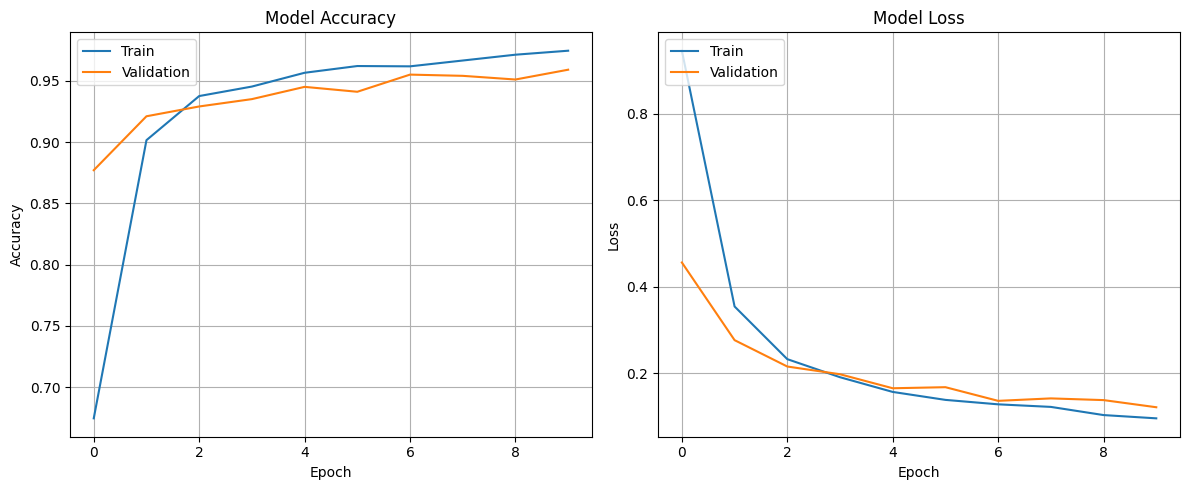

In [8]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()